# 📈 销售趋势分析

**目标**：分析销售额、订单量随时间的变化趋势，识别季节性和增长模式

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置 seaborn 样式
sns.set_style('whitegrid')
sns.set_palette('husl')

print('库加载完成！')

库加载完成！


In [2]:
# 加载数据
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# 转换日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f'数据加载成功！共 {len(df)} 条记录')
print(f'时间范围：{df["Order Date"].min().date()} ~ {df["Order Date"].max().date()}')

数据加载成功！共 9994 条记录
时间范围：2014-01-03 ~ 2017-12-30


## 1. 整体销售概况

In [3]:
# 计算核心指标
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = total_sales / total_orders
profit_margin = total_profit / total_sales * 100

print('='*50)
print('📊 核心指标')
print('='*50)
print(f'总销售额：${total_sales:,.2f}')
print(f'总利润：${total_profit:,.2f}')
print(f'利润率：{profit_margin:.2f}%')
print(f'总订单数：{total_orders:,}')
print(f'总客户数：{total_customers:,}')
print(f'平均客单价：${avg_order_value:,.2f}')

📊 核心指标
总销售额：$2,297,200.86
总利润：$286,397.02
利润率：12.47%
总订单数：5,009
总客户数：793
平均客单价：$458.61


## 2. 月度销售趋势

In [4]:
# 按月聚合
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
monthly_sales['Month'] = monthly_sales['Order Date'].dt.strftime('%Y-%m')

# 交互式图表
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('月度销售额', '月度订单量'),
    vertical_spacing=0.15
)

# 销售额趋势
fig.add_trace(
    go.Scatter(
        x=monthly_sales['Month'],
        y=monthly_sales['Sales'],
        mode='lines+markers',
        name='销售额',
        line=dict(color='#2E86AB', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

# 订单量趋势
fig.add_trace(
    go.Bar(
        x=monthly_sales['Month'],
        y=monthly_sales['Order ID'],
        name='订单量',
        marker_color='#A23B72'
    ),
    row=2, col=1
)

fig.update_layout(
    height=600,
    title_text='月度销售趋势',
    showlegend=False,
    template='plotly_white'
)

fig.show()

## 3. 年度对比分析

📊 年度销售数据
 Order Year       Sales     Profit  Order ID  Sales Growth  Profit Growth
       2014 484247.4981 49543.9741       969           NaN            NaN
       2015 470532.5090 61618.6037      1038     -2.832227      24.371540
       2016 609205.5980 81795.1743      1315     29.471521      32.744284
       2017 733215.2552 93439.2696      1687     20.355962      14.235675


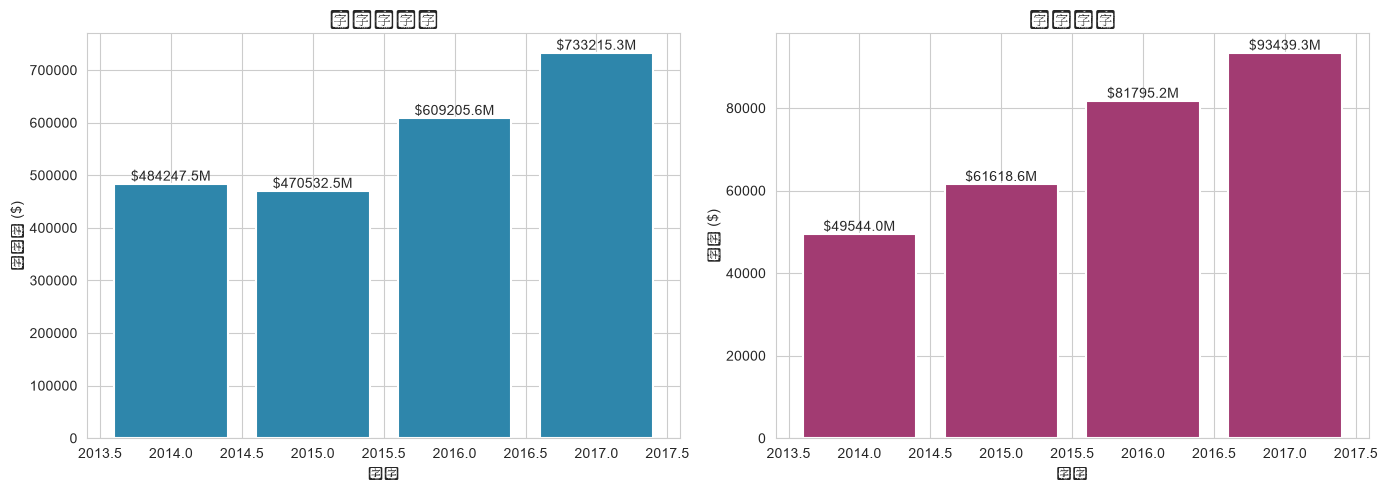

In [5]:
# 按年聚合
yearly_sales = df.groupby('Order Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

# 计算同比增长率
yearly_sales['Sales Growth'] = yearly_sales['Sales'].pct_change() * 100
yearly_sales['Profit Growth'] = yearly_sales['Profit'].pct_change() * 100

print('='*50)
print('📊 年度销售数据')
print('='*50)
print(yearly_sales.to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 销售额柱状图
bars1 = axes[0].bar(yearly_sales['Order Year'], yearly_sales['Sales'], 
                    color='#2E86AB', edgecolor='white', linewidth=1.5)
axes[0].set_title('年度销售额', fontsize=14, fontweight='bold')
axes[0].set_xlabel('年份')
axes[0].set_ylabel('销售额 ($)')
axes[0].bar_label(bars1, fmt='$%.1fM', fontsize=10)

# 利润柱状图
bars2 = axes[1].bar(yearly_sales['Order Year'], yearly_sales['Profit'],
                    color='#A23B72', edgecolor='white', linewidth=1.5)
axes[1].set_title('年度利润', fontsize=14, fontweight='bold')
axes[1].set_xlabel('年份')
axes[1].set_ylabel('利润 ($)')
axes[1].bar_label(bars2, fmt='$%.1fM', fontsize=10)

plt.tight_layout()
plt.show()

## 4. 季节性分析

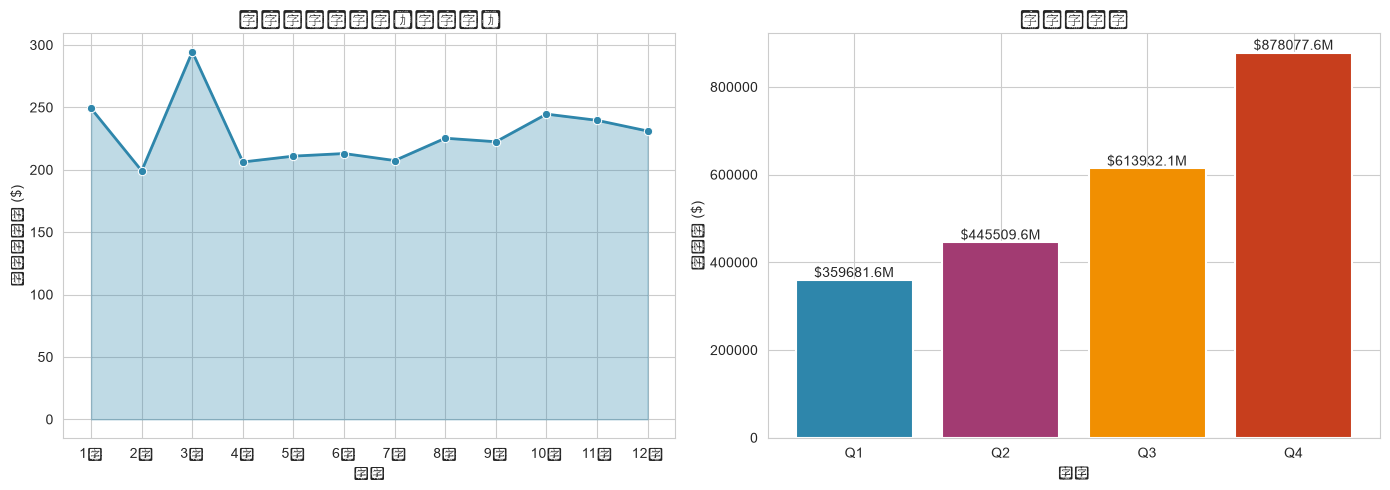

In [6]:
# 按月份分析季节性
monthly_pattern = df.groupby('Order Month').agg({
    'Sales': 'mean',
    'Profit': 'mean'
}).reset_index()

# 按季度分析
quarterly_pattern = df.groupby('Order Quarter').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 月度季节性
sns.lineplot(data=monthly_pattern, x='Order Month', y='Sales', 
             marker='o', color='#2E86AB', linewidth=2, ax=axes[0])
axes[0].fill_between(monthly_pattern['Order Month'], monthly_pattern['Sales'], 
                     alpha=0.3, color='#2E86AB')
axes[0].set_title('月度平均销售额（季节性）', fontsize=14, fontweight='bold')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('平均销售额 ($)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['1月','2月','3月','4月','5月','6月',
                          '7月','8月','9月','10月','11月','12月'])

# 季度对比
quarter_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = axes[1].bar(quarterly_pattern['Order Quarter'], quarterly_pattern['Sales'],
                   color=quarter_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('季度销售额', fontsize=14, fontweight='bold')
axes[1].set_xlabel('季度')
axes[1].set_ylabel('销售额 ($)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
axes[1].bar_label(bars, fmt='$%.1fM', fontsize=10)

plt.tight_layout()
plt.show()

## 5. 星期销售分布

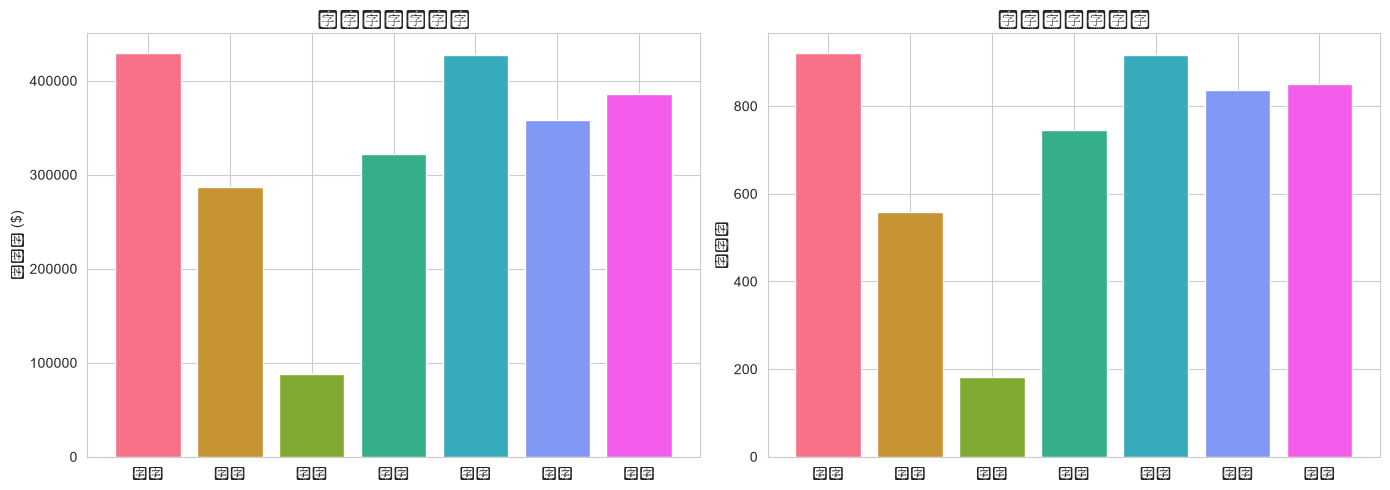

In [7]:
# 按星期分析
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('Order Day of Week').agg({
    'Sales': ['sum', 'mean'],
    'Order ID': 'nunique'
}).reset_index()
day_sales.columns = ['Day', 'Total Sales', 'Avg Sales', 'Orders']
day_sales['Day'] = pd.Categorical(day_sales['Day'], categories=day_order, ordered=True)
day_sales = day_sales.sort_values('Day')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 星期销售额
colors = sns.color_palette('husl', 7)
bars = axes[0].bar(range(7), day_sales['Total Sales'], color=colors, edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['周一','周二','周三','周四','周五','周六','周日'])
axes[0].set_title('星期销售额分布', fontsize=14, fontweight='bold')
axes[0].set_ylabel('销售额 ($)')

# 星期订单量
bars = axes[1].bar(range(7), day_sales['Orders'], color=colors, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['周一','周二','周三','周四','周五','周六','周日'])
axes[1].set_title('星期订单量分布', fontsize=14, fontweight='bold')
axes[1].set_ylabel('订单量')

plt.tight_layout()
plt.show()

## 6. 关键发现

In [8]:
# 计算关键指标
best_month = monthly_pattern.loc[monthly_pattern['Sales'].idxmax()]
worst_month = monthly_pattern.loc[monthly_pattern['Sales'].idxmin()]
best_quarter = quarterly_pattern.loc[quarterly_pattern['Sales'].idxmax()]

print('='*50)
print('💡 关键发现')
print('='*50)
print(f'\n📈 最佳月份：{int(best_month["Order Month"])}月（平均销售额 ${best_month["Sales"]:,.2f}）')
print(f'📉 最低月份：{int(worst_month["Order Month"])}月（平均销售额 ${worst_month["Sales"]:,.2f}）')
print(f'\n🏆 最佳季度：Q{int(best_quarter["Order Quarter"])}（销售额 ${best_quarter["Sales"]:,.2f}）')

# 销售额最高的星期
best_day = day_sales.loc[day_sales['Total Sales'].idxmax()]
print(f'\n📅 最佳星期：{best_day["Day"]}（销售额 ${best_day["Total Sales"]:,.2f}）')

💡 关键发现

📈 最佳月份：3月（平均销售额 $294.55）
📉 最低月份：2月（平均销售额 $199.17）

🏆 最佳季度：Q4（销售额 $878,077.56）

📅 最佳星期：Monday（销售额 $428,937.82）
